Build a high-performance crypto ranking model by combining features from multiple sources:
- **CrowdCent**: 80 features + targets (base universe)
- **YIEDL**: ~3,600 features (PVM, sentiment, on-chain)
- **Numerai Crypto v2.0**: Additional features

**What you'll learn:**
1. Download and merge datasets from multiple sources
2. Build sklearn Pipelines with feature selection (SelectFromModel, MRMR, etc.)
3. Train diverse models: XGBoost, RandomForest, and LSTM
4. Create ensembles and submit to multiple slots
5. Submit to the CrowdCent Challenge

<div align="center">
  <a target="_blank" href="https://colab.research.google.com/github/crowdcent/crowdcent-challenge/blob/main/docs/tutorials/advanced-multi-data-slots.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>
</div>

## Part 0: Setup

In [1]:
import os

os.environ["KERAS_BACKEND"] = "torch"  # Must be before centimators import

import crowdcent_challenge as cc
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

from xgboost import XGBRegressor

from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklego.model_selection import TimeGapSplit
from sklego.preprocessing import ColumnSelector

from centimators.model_estimators import LSTMRegressor
from centimators.losses import SpearmanCorrelation

from crowdcent_challenge.scoring import evaluate_hyperliquid_submission
import altair as alt

# Auto-fetch tutorial helpers if not available locally
from pathlib import Path

if not Path("utils.py").exists():
    import urllib.request

    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/crowdcent/crowdcent-challenge/main/docs/tutorials/utils.py",
        "utils.py",
    )
from utils import load_training_data, load_inference_data, summarize, plot_cv

# Enable interactive HTML diagrams for sklearn pipelines
# Enable metadata routing to pass fit_params (like epochs) through pipelines
set_config(display="diagram", enable_metadata_routing=True)

In [2]:
# Set your API key
CROWDCENT_API_KEY = "YOUR_API_KEY_HERE"  # Get from https://crowdcent.com/profile

## Part 1: Load Data

The `load_training_data()` helper handles everything end-to-end:
- **CrowdCent**: Downloads training data via API
- **YIEDL**: Downloads historical dataset (~9.7 GB raw), filters to CrowdCent universe (~500 MB cached)
- **Numerai**: Downloads Crypto v2.0 training data

All sources are filtered to the CrowdCent symbol universe and merged with proper date alignment and column prefixing (`yiedl_*`, `nmr_*`). Data is cached in `data/` after first download.

> **Note**: The YIEDL historical download is large (~9.7 GB, needs ~20 GB temp disk). Use `include_yiedl=False` for faster iteration without YIEDL features.

In [3]:
# Initialize CrowdCent client
client = cc.ChallengeClient(
    challenge_slug="hyperliquid-ranking",  
    # api_key=CROWDCENT_API_KEY
)

2026-02-18 00:03:22,537 - INFO - ChallengeClient initialized for 'hyperliquid-ranking' at URL: https://crowdcent.com/api


In [4]:
# Load and merge all training data sources (one-liner!)
merged = load_training_data(client)

CrowdCent: (236116, 85)
YIEDL: (227303, 3671)
Numerai: (461896, 27)
CC after 2020 filter: (230096, 85)
After YIEDL join: (230096, 3755)
Numerai after weekend ffill: (192487, 24)
After Numerai join: (230096, 3777)
Final merged: (230096, 3776)


In [5]:
# Quick summary of merged data
summarize(merged)

Shape: (230096, 3776)
Date range: 2020-01-01 00:00:00 to 2025-12-15 00:00:00

Features: 3771 total
  - CrowdCent: 80
  - YIEDL:     3669
  - Numerai:   22


## Part 2: Feature Exploration

Before building models, we need to understand our feature landscape. In this section, we'll:

1. **Understand our targets**: Distribution and autocorrelation (which affects cross-validation)
2. **Explore the universe**: How it evolved over time and data source coverage
3. **Deep dive into each source**: CrowdCent, YIEDL, and Numerai feature characteristics
4. **Analyze feature quality**: Which features correlate best with targets

This exploration directly informs our modeling choices in Part 3.

### Target Overview

Let's start by understanding our prediction targets. The targets are **cross-sectional ranks** of forward returns (10-day and 30-day), scaled to [0, 1].

In [6]:
merged.sample(n=2500, seed=42).unpivot(
    on=["target_10d", "target_30d"], variable_name="target", value_name="value"
).plot.boxplot(x="target", y="value").properties(
    width=500, height=300, title="Targets: cross-sectional ranks scaled to [0, 1]"
)

alt.Chart(...)

### Target Autocorrelation: Why Overlapping Targets Matter

The targets are **forward-looking returns** (10-day and 30-day). Because they overlap in time, consecutive targets share most of their return window, creating high autocorrelation at short lags.

- **target_10d**: Autocorrelation drops to ~0 after lag 10 (the return window)
- **target_30d**: Stays correlated much longer, only reaching ~0 around lag 30

This is important for cross-validation - we need gaps between train/val to avoid leakage.

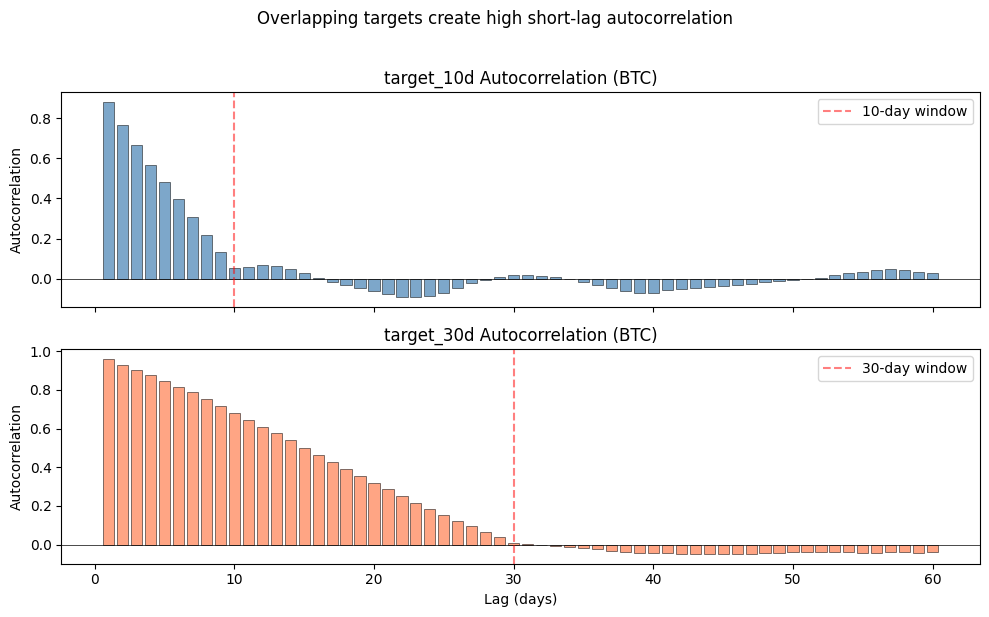

In [7]:
# Target autocorrelation - shows why we need gaps in cross-validation
btc = merged.filter(pl.col("id") == "BTC").sort("date")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for ax, target, color in zip(
    axes, ["target_10d", "target_30d"], ["steelblue", "coral"]
):
    values = btc[target].to_numpy()
    autocorrs = [np.corrcoef(values[:-lag], values[lag:])[0, 1] for lag in range(1, 61)]

    ax.bar(
        range(1, 61),
        autocorrs,
        color=color,
        alpha=0.7,
        edgecolor="black",
        linewidth=0.5,
    )
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel("Autocorrelation")
    ax.set_title(f"{target} Autocorrelation (BTC)")

    # Mark the target window
    window = 10 if "10d" in target else 30
    ax.axvline(
        window, color="red", linestyle="--", alpha=0.5, label=f"{window}-day window"
    )
    ax.legend()

axes[1].set_xlabel("Lag (days)")
plt.suptitle("Overlapping targets create high short-lag autocorrelation", y=1.02)
plt.tight_layout()
plt.show()

### Universe Evolution

The CrowdCent universe tracks the available data for the universe of crypto perpetual futures listed on Hyperliquid. This has grown significantly over time - from ~50 tickers in 2020 to ~205 in 2025. This growth impacts feature and target distributions since newer coins have different characteristics than established ones.

In [8]:
# Universe size over time
tickers_over_time = (
    merged.group_by(pl.col("date").dt.date().alias("date"))
    .agg(pl.col("id").n_unique().alias("n_tickers"))
    .sort("date")
)

tickers_over_time.plot.area(
    x="date",
    y="n_tickers",
).properties(title="Universe Size Over Time", width=700, height=300)

alt.Chart(...)

### Data Source Coverage

We merge three data sources, each with different coverage:
- **CrowdCent**: 80 features, 0% null (base universe)
- **YIEDL**: 3,669 features (onchain, sentiment, pvm), ~9% null
- **Numerai**: 22 features, ~20% null (starts 2020, no weekends - we forward-fill)

The Numerai nulls are from CC symbols not in Numerai (~10%) and newer symbols added after Numerai's coverage. Pretty good coverage!

In [9]:
# Data source coverage by year
nmr_col = [c for c in merged.columns if c.startswith("nmr_")][0]
yiedl_col = [c for c in merged.columns if c.startswith("yiedl_")][0]

coverage = (
    merged.with_columns(pl.col("date").dt.year().alias("year"))
    .group_by("year")
    .agg(
        pl.len().alias("total"),
        (pl.col(nmr_col).is_not_null().sum() / pl.len() * 100).alias("numerai_pct"),
        (pl.col(yiedl_col).is_not_null().sum() / pl.len() * 100).alias("yiedl_pct"),
    )
    .sort("year")
)

coverage_long = coverage.unpivot(
    index="year",
    on=["numerai_pct", "yiedl_pct"],
    variable_name="source",
    value_name="coverage",
)

alt.Chart(coverage_long.to_pandas()).mark_bar().encode(
    x=alt.X("year:O", title="Year"),
    y=alt.Y("coverage:Q", title="Coverage (%)"),
    color=alt.Color("source:N", title="Data Source"),
    xOffset="source:N",
).properties(title="Data Source Coverage by Year", width=500, height=300)

alt.Chart(...)

### CrowdCent Feature Breakdown

CrowdCent provides **80 carefully curated features** that form the foundation of our dataset. Unlike YIEDL (3,600+ raw features) or Numerai (22 preprocessed features), CrowdCent features have a specific temporal structure:

**Lag Structure:** Each of the 20 base features comes in 4 variants:
- `feature_X_lag0` - current day value
- `feature_X_lag5` - 5 days ago
- `feature_X_lag10` - 10 days ago  
- `feature_X_lag15` - 15 days ago

This gives us 20 base features × 4 lags = **80 features total**.

**Why this matters:**
- **For tree models**: Each lag is an independent feature capturing different information horizons
- **For LSTMs**: The lags form a natural time series - the same underlying signal at different points in time

### Features as Time Series: The Sequence Model Opportunity (e.g. LSTM, Transformer)

Each feature comes in multiple lags (lag0, lag5, lag10, lag15), already normalized between 0 and 1. When we shift lag15 back by 15 days, we see it perfectly aligns with lag0 - they're the same underlying signal!

This temporal structure is perfect for sequence models like LSTMs, which can learn patterns across the lagged features rather than treating them as independent inputs. You can think of an LSTM being aware of the entire trajectory that lag0 has taken.

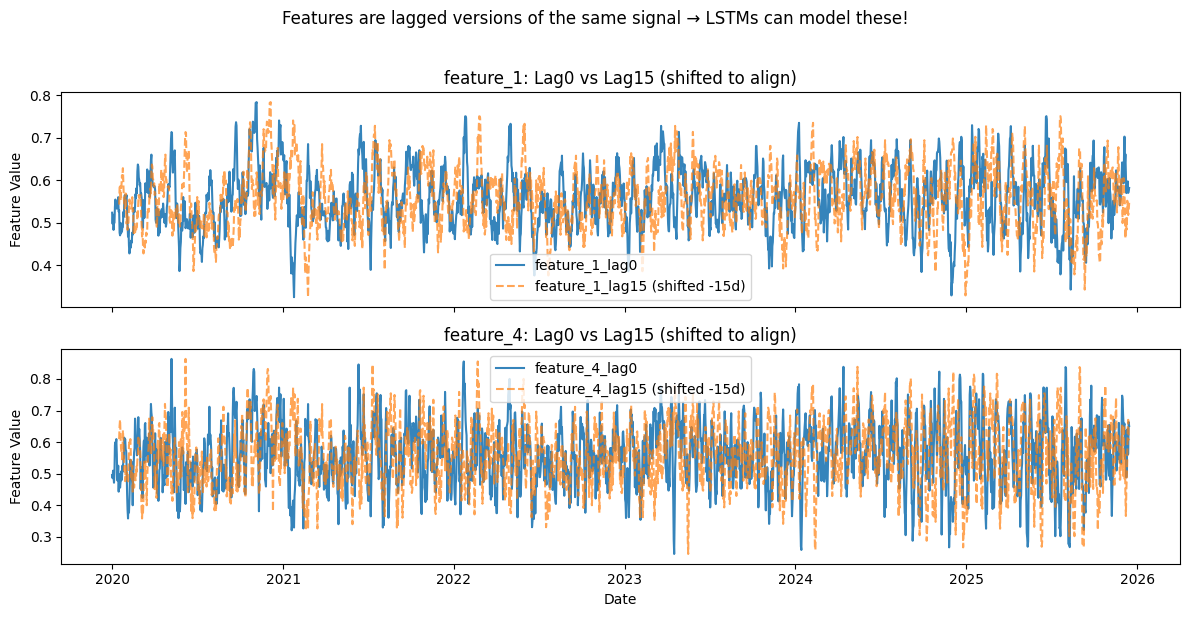

In [10]:
# CrowdCent feature structure
cc_feats = [
    c
    for c in merged.columns
    if c.startswith("feature_") and not c.startswith(("yiedl_", "nmr_"))
]

# Lag overlay for BTC - showing lag0 vs lag15 shifted to align
btc = merged.filter(pl.col("id") == "BTC").sort("date")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax, feat_base in zip(axes, ["feature_1", "feature_4"]):
    dates = btc["date"].to_numpy()
    lag0 = btc[f"{feat_base}_lag0"].to_numpy()
    lag15 = btc[f"{feat_base}_lag15"].to_numpy()

    ax.plot(dates, lag0, label=f"{feat_base}_lag0", alpha=0.9)
    ax.plot(
        dates[15:],
        lag15[:-15],
        label=f"{feat_base}_lag15 (shifted -15d)",
        alpha=0.7,
        linestyle="--",
    )
    ax.set_ylabel("Feature Value")
    ax.set_title(f"{feat_base}: Lag0 vs Lag15 (shifted to align)")
    ax.legend()

axes[1].set_xlabel("Date")
plt.suptitle(
    "Features are lagged versions of the same signal → LSTMs can model these!", y=1.02
)
plt.tight_layout()
plt.show()


### YIEDL Feature Breakdown

YIEDL provides 3,669 features across three categories:
- **Onchain** (1,653): Blockchain metrics - hardest to obtain but potentially noisiest
- **Sentiment** (1,596): Social/news signals
- **PVM** (420): Price-volume-momentum indicators

The onchain features have the most missing data since not all tokens have on-chain analytics.

In [11]:
# YIEDL feature categories
yiedl_feats = [c for c in merged.columns if c.startswith("yiedl_")]
cat_df = (
    pl.DataFrame({"feature": yiedl_feats})
    .with_columns(
        pl.col("feature")
        .str.replace("yiedl_", "")
        .str.split("_")
        .list.first()
        .alias("category")
    )
    .group_by("category")
    .len()
    .rename({"len": "count"})
)

alt.Chart(cat_df.to_pandas()).mark_bar().encode(
    x=alt.X("count:Q", title="Number of Features"),
    y=alt.Y("category:N", sort="-x", title="Category"),
    color=alt.value("steelblue"),
).properties(title="YIEDL Feature Categories", width=400, height=200)


alt.Chart(...)

### Numerai Feature Breakdown

Numerai Crypto v2.0 provides 22 features - standard technical and fundamental indicators at two timeframes (20-day and 60-day). Unlike Numerai Classic, these features are **named and interpretable**:

- **Price**: bollinger, close_avg, close_ewa, momentum, RSI, sharpe_ratio, volatility
- **Volume**: volume_avg, volume_ewa  
- **Fundamentals**: market_cap_avg, market_cap_ewa

In [12]:
# Numerai feature correlations
nmr_feats = [c for c in merged.columns if c.startswith("nmr_")]
nmr_df = pl.DataFrame(
    [
        {
            "feature": f.replace("nmr_feature_", ""),
            "correlation": merged.select(pl.corr(f, "target_10d")).item(),
        }
        for f in nmr_feats
    ]
).sort("correlation", descending=True)

nmr_df.plot.bar(
    y=alt.Y("feature:N", sort="-x"),
    x="correlation",
).properties(width=500, height=300, title="Numerai Features: Correlation with Target")

alt.Chart(...)

### Feature "Quality:" CrowdCent vs YIEDL vs Numerai

CrowdCent's 80 features have higher median correlation with targets than YIEDL's 3,669 features. This makes sense - CrowdCent features are curated, while YIEDL is a large feature dump.

This suggests we should use **feature selection** (like `SelectFromModel` or MRMR) to pick the best YIEDL features rather than using all of them.

In [13]:
# Feature quality comparison: CrowdCent vs YIEDL
cc_ics = [abs(merged.select(pl.corr(f, "target_10d")).item()) for f in cc_feats]
yiedl_ics = [abs(merged.select(pl.corr(f, "target_10d")).item()) for f in yiedl_feats]
nmr_ics = [abs(merged.select(pl.corr(f, "target_10d")).item()) for f in nmr_feats]

# Create a DataFrame for boxplot
ic_df = pl.DataFrame(
    {
        "ic": cc_ics + yiedl_ics + nmr_ics,
        "source": (
            ["CrowdCent (80)"] * len(cc_ics)
            + ["YIEDL (3669)"] * len(yiedl_ics)
            + ["Numerai (22)"] * len(nmr_ics)
        ),
    }
)

ic_df.plot.boxplot(
    x="source",
    y="ic",
).properties(
    width=500,
    height=300,
    title="Feature Quality: CrowdCent vs YIEDL (Higher = more predictive)",
)

alt.Chart(...)

### Drilling Down into Feature Correlations with Target

The most predictive features are the **lag0** versions (current day values). However, having lagged features (lag5, lag10, lag15) is still valuable - especially when modeled as sequences using LSTMs (as we saw in the CrowdCent breakdown above).

Let's see which specific CrowdCent features have the strongest correlation with our target.

In [14]:
# Top feature correlations with target
cc_feats = [
    c
    for c in merged.columns
    if c.startswith("feature_") and not c.startswith(("yiedl_", "nmr_"))
]
corr_df = (
    pl.DataFrame(
        [
            {
                "feature": f,
                "correlation": merged.select(pl.corr(f, "target_10d")).item(),
            }
            for f in cc_feats
        ]
    )
    .sort("correlation", descending=True)
    .head(20)
)

corr_df.plot.bar(
    x="correlation",
    y=alt.Y("feature:N", sort="-x"),
).properties(title="Top 20 CrowdCent Features by Correlation", width=500, height=400)

alt.Chart(...)

## Part 3: Modeling with sklearn Pipelines

Now that our data is ready, it is time to model! Given that we are dealing with different datasets and we may want some columns to be in some models, but not in others, sklearn pipelines are a perfect tool for the job!

sklearn's composable primitives let you build powerful ML workflows:
- **Pipeline**: Chain preprocessing → feature selection → model
- **SelectFromModel**: Feature selection based on model importance (scale-invariant!)
- **MRMR**: Maximum Relevance Minimum Redundancy - selects diverse, informative features
- **cuML acceleration**: Most sklearn estimators can be automatically dispatched to GPU if you install cuML acceleration

In [ ]:
# Define feature and target columns
target_cols = ["target_10d", "target_30d"]
meta_cols = ["id", "eodhd_id", "date"] + target_cols
feature_cols = [c for c in merged.columns if c not in meta_cols]

# Identify feature groups by source (useful for source-specific processing)
cc_features = [c for c in feature_cols if not c.startswith(("yiedl_", "nmr_"))]
yiedl_features = [c for c in feature_cols if c.startswith("yiedl_")]
nmr_features = [c for c in feature_cols if c.startswith("nmr_")]

print(f"Total features: {len(feature_cols)}")
print(f"  - CrowdCent:  {len(cc_features):>5} (base features with temporal structure)")
print(f"  - YIEDL:      {len(yiedl_features):>5} (PVM, sentiment, on-chain)")
print(f"  - Numerai:    {len(nmr_features):>5} (Numerai Crypto v2.0)")
print(f"Targets: {target_cols}")

In [ ]:
# Pipeline with SelectFromModel: selects features by XGBoost importance (scale-invariant!)
# This works well because it picks features that actually help predict, not just high variance
xgb_pipeline = Pipeline(
    [
        (
            "select",
            SelectFromModel(
                XGBRegressor(
                    n_estimators=500, max_depth=3, random_state=42, device="cuda"
                ),
                threshold="median",
                max_features=500,  # Cap at 300 most important features
            ),
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=5000, max_depth=7, random_state=42, device="cuda"
            ),
        ),
    ]
)

# Display the pipeline - sklearn renders this as an interactive HTML diagram!
# This is YOUR pipeline to customize. Swap components, tune params, experiment.
xgb_pipeline.fit_params = {}  # No special fit params needed
xgb_pipeline

In [ ]:
# LSTM: Leverages temporal structure in CrowdCent features
# CrowdCent features have built-in lag structure: 0, 5, 10, 15 days lookback
# LSTM learns patterns across these timesteps - only works with CrowdCent features
# (YIEDL/Numerai features don't have this temporal structure)
lag_windows = [0, 5, 10, 15]
n_features_per_timestep = len(cc_features) // len(lag_windows)

lstm_pipeline = Pipeline(
    [
        ("select_cc", ColumnSelector(cc_features)),  # Only CrowdCent features
        (
            "model",
            LSTMRegressor(
                output_units=2,  # 10d and 30d targets
                lag_windows=lag_windows,
                n_features_per_timestep=n_features_per_timestep,
                loss_function=SpearmanCorrelation(),
            ).set_fit_request(epochs=True),  # Enable epochs metadata routing
        ),
    ]
)

lstm_pipeline.fit_params = {"epochs": 1}
lstm_pipeline

In [ ]:
# Three diverse models: tree-based (XGB) + neural (LSTM)
models = {
    "xgb_pipeline": xgb_pipeline,  # XGBoost + SelectFromModel
    "lstm": lstm_pipeline,  # LSTM on CrowdCent features only
}

## Scoring Metrics

Before we run cross-validation, let's understand how we'll measure success.

| Metric | What it measures | Random | Top live scores |
|--------|------------------|:------:|:----------:|
| **Spearman** | Overall rank correlation | 0.00 | 0.14–0.20 |
| **Symmetric NDCG@40** | Top AND bottom of list accuracy | **0.55** | 0.63–0.66 |

### Why "Symmetric"?

In finance, identifying the **worst** performers is as important as the best. Shorting losers is as valuable as buying winners in a market neutral portfolio. Symmetric NDCG evaluates both ends:

```python
final_score = (ndcg_top_k + ndcg_bottom_k) / 2
```

### Interpretation

- **NDCG = 0.55** → Random guessing  
- **NDCG = 0.63** → Top leaderboard (small edge, big impact)  
- **Spearman = 0.14** → Strong directional signal

## Part 4: Cross-Validation

### Why TimeGapSplit?

Recall from Part 2 that our targets have high autocorrelation due to overlapping return windows - `target_30d` doesn't drop to ~0 until around lag 30. This means we can't use random cross-validation (future information would leak into training). Instead, we use `TimeGapSplit` with carefully chosen parameters:

- **`gap_duration=30 days`**: Matches the longest target horizon (30d). Ensures validation targets don't overlap with training targets' return windows.
- **`valid_duration=100 days`**: Provides ~100 validation days per fold - enough for statistically meaningful evaluation while leaving room for multiple folds.
- **`n_splits=3`**: Balances coverage of different time periods vs. computational cost.
- **`window="rolling"`**: Uses a fixed-size training window that moves forward, rather than expanding. This avoids letting the model rely on very old patterns that may no longer be relevant in crypto's fast-evolving markets.

These cross-validation parameters can also be improved upon and you should experiment with different values, while always keeping leakage in mind. Let's take a look at what our splits look like at an intuitive level:

In [ ]:
# TimeGapSplit setup
cv = TimeGapSplit(
    date_serie=merged["date"],
    valid_duration=timedelta(days=100),
    gap_duration=timedelta(days=30),
    n_splits=3,
    window="rolling",
)

cv.summary(merged)

In [ ]:
# Visualize the CV fold structure
plot_cv(cv, merged)

In [ ]:
# Helper to collect predictions (gets targets directly from val_df)
def collect_preds(val_df, preds, model_name):
    return pl.DataFrame(
        {
            "date": val_df["date"],
            "model": model_name,
            "pred_10d": preds[:, 0],
            "target_10d": val_df["target_10d"],
            "pred_30d": preds[:, 1],
            "target_30d": val_df["target_30d"],
        }
    )


# Helper to score from predictions DataFrame (reuses stored data)
def score_preds(df: pl.DataFrame) -> dict[str, float]:
    return evaluate_hyperliquid_submission(
        y_true_10d=df["target_10d"].to_numpy(),
        y_pred_10d=df["pred_10d"].to_numpy(),
        y_true_30d=df["target_30d"].to_numpy(),
        y_pred_30d=df["pred_30d"].to_numpy(),
    )


# Run CV for each model
cv_results, all_val_preds = [], []

# For each fold
for fold, (train_idx, val_idx) in enumerate(cv.split(merged)):
    train_df, val_df = merged[train_idx], merged[val_idx]
    X_train, y_train = train_df[feature_cols], train_df[target_cols]
    X_val = val_df[feature_cols]

    print(f"\nFold {fold + 1}: train={len(train_df)}, val={len(val_df)}")

    # For each model, train and predict on this fold'straining/validation split
    fold_preds = []
    for name, model in models.items():
        print(f"  Training {name}...")
        model.fit(X_train, y_train, **model.fit_params)
        preds = model.predict(X_val)

        pred_df = collect_preds(val_df, preds, name)
        fold_preds.append(pred_df)
        all_val_preds.append(pred_df)

        scores = score_preds(pred_df)
        scores["model"], scores["fold"] = name, fold
        cv_results.append(scores)
        print(
            f"    spearman_10d={scores['spearman_10d']:.4f}, spearman_30d={scores['spearman_30d']:.4f}"
        )

    # Ensemble: average predictions across models
    ensemble_df = (
        pl.concat(fold_preds)
        .group_by(["date", "target_10d", "target_30d"], maintain_order=True)
        .agg(pred_10d=pl.mean("pred_10d"), pred_30d=pl.mean("pred_30d"))
        .with_columns(model=pl.lit("ensemble"))
    )
    all_val_preds.append(ensemble_df)

    scores = score_preds(ensemble_df)
    scores["model"], scores["fold"] = "ensemble", fold
    cv_results.append(scores)
    print(
        f"  Ensemble: spearman_10d={scores['spearman_10d']:.4f}, spearman_30d={scores['spearman_30d']:.4f}"
    )

combined_preds = pl.concat(all_val_preds, how="diagonal")

## Part 5: Evaluate & Visualize

In [ ]:
# Aggregate CV results
results_df = pl.DataFrame(cv_results)

metric_cols = ["spearman_10d", "spearman_30d", "ndcg@40_10d", "ndcg@40_30d"]
summary = (
    results_df.group_by("model")
    .agg([pl.col(col).mean().alias(f"mean_{col}") for col in metric_cols])
    .sort("mean_spearman_30d", descending=True)
)

print("CV Results Summary:")
summary

### Interpreting the Results

**How do these scores compare to baselines?**

| Model | Spearman 30d | vs Random (0.00) | NDCG@40 30d | vs Random (0.55) |
|-------|--------------|------------------|-------------|------------------|
| Random baseline | 0.00 | — | 0.55 | — |
| Top leaderboard | 0.14–0.20 | +0.14–0.20 | 0.63–0.66 | +0.08–0.11 |

**Key observations:**
- **Spearman** measures overall rank correlation. Values above 0.10 indicate meaningful signal.
- **NDCG@40** focuses on the top and bottom 40 assets - crucial for portfolio construction. The gap from 0.55 (random) to 0.63+ is the edge that drives returns.
- **Ensemble** typically outperforms individual models by averaging out model-specific errors.
- **Fold variance** matters: if scores vary wildly across folds, the model may be unstable or overfitting to specific market regimes.

In [ ]:
# Visualization
chart = (
    alt.Chart(results_df.to_pandas())
    .mark_bar()
    .encode(
        x=alt.X("model:N", sort="-y"),
        y=alt.Y("mean(ndcg@40_30d):Q", title="Mean NDCG@40 30d"),
        color="model:N",
    )
    .properties(width=400, height=300, title="Model Comparison (CV)")
)
chart

### Per-Day Correlation Analysis

Let's see how model performance varies day-by-day across validation periods. Daily scores show that, although the mean is high, the variance of scores is also very high, with some days scoring worse than -0.20 in spearman correlation.

In [ ]:
# Calculate daily scores across all OOS days
daily_scores = (
    pl.DataFrame(
        [
            {
                "date": date,
                "model": model,
                **evaluate_hyperliquid_submission(
                    y_true_10d=g["target_10d"],
                    y_pred_10d=g["pred_10d"],
                    y_true_30d=g["target_30d"],
                    y_pred_30d=g["pred_30d"],
                ),
            }
            for (date, model), g in combined_preds.group_by(["date", "model"])
        ]
    )
    .sort(["model", "date"])
    .with_columns(  # add moving average
        [
            pl.col(c)
            .rolling_mean(window_size=7, min_samples=1)
            .over("model")
            .alias(f"{c}_ma7")
            for c in ["spearman_10d", "spearman_30d"]
        ]
    )
)


# Plot daily scores with 7-day moving average
def plot_daily_scores(df, metric="spearman_10d"):
    pdf = df.to_pandas()
    points = (
        alt.Chart(pdf)
        .mark_point(opacity=0.5, size=15)
        .encode(
            x="date:T",
            y=f"{metric}:Q",
            color="model:N",
            tooltip=["date:T", "model:N", f"{metric}:Q"],
        )
    )
    line = (
        alt.Chart(pdf)
        .mark_line(strokeWidth=2)
        .encode(x="date:T", y=f"{metric}_ma7:Q", color="model:N")
    )
    return (points + line).properties(
        width=500, height=200, title=f"Daily {metric} (7-day MA)"
    )


plot_daily_scores(daily_scores, "spearman_10d") & plot_daily_scores(
    daily_scores, "spearman_30d"
)

## Part 6: Final Re-Training & Submission

You would generally use the above cross validation scheme to grid search or optimize your hyperparameters. After that is done, you can optionally ensemble your per-fold models and/or re-train your model's with the best hyperparameters on all of the data.

Here, we will retrain the models on all of the data before loading in inference/live features for predicting and submitting.

In [ ]:
# Retrain on full data
X_full = merged[feature_cols]
y_full = merged[target_cols]

print("Training final models on full data...")
final_models = {}
for name, model in models.items():
    print(f"  {name}...")
    model.fit(X_full, y_full, **model.fit_params)
    final_models[name] = model
print("Done!")

### Load all inference data (LIVE) from 3 sources and merge

In [ ]:
# Load CrowdCent inference data with live YIEDL/Numerai (one-liner!)
inference_data = load_inference_data(client)

### Predict on inference data

In [ ]:
all_preds = {}
for name, model in final_models.items():
    preds = model.predict(inference_data[feature_cols])
    all_preds[name] = preds

# Ensemble
ensemble_preds = np.mean(list(all_preds.values()), axis=0)
all_preds["ensemble"] = ensemble_preds

In [ ]:
# Prepare submission DataFrames
def make_submission_df(preds, ids):
    """Create valid submission DataFrame with predictions clipped to [0,1]."""
    # Handle both Series and list inputs for ids
    id_values = ids.to_list() if hasattr(ids, "to_list") else list(ids)
    return pl.DataFrame(
        {
            "id": id_values,
            "pred_10d": np.clip(preds[:, 0], 0, 1).tolist(),
            "pred_30d": np.clip(preds[:, 1], 0, 1).tolist(),
        }
    )


submissions = {
    name: make_submission_df(preds, inference_data["id"])
    for name, preds in all_preds.items()
}

submissions["ensemble"]

In [ ]:
# Submit our ensemble predictions to the challenge
print("Submitting ensemble predictions...")
result = client.submit_predictions(df=submissions["ensemble"])
print(f"Success! Submission ID: {result.get('id')}")

That's it! Your predictions are now live. Track your performance on the [leaderboard](https://crowdcent.com/leaderboard/).

## Part 7: Advanced - Multi-Slot Strategies

CrowdCent allows you to submit up to **5 different predictions** to the same challenge using "slots." This lets you test different strategies simultaneously and see which performs best. See the [Hyperliquid Ranking docs](https://docs.crowdcent.com/hyperliquid-ranking/) for more details.

The simple submission above used slot 1 (the default). Now let's submit custom weighted ensembles and submit them to different slots for diversification:

In [ ]:
# Example: weighted ensembles favoring different models per slot
weight_strategies = {
    2: {"xgb_pipeline": 0.7, "lstm": 0.3},  # xgb-heavy
    3: {"xgb_pipeline": 0.3, "lstm": 0.7},  # lstm-heavy
}

for slot_num, weights in weight_strategies.items():
    weighted_preds = sum(w * all_preds[m] for m, w in weights.items())
    sub_df = make_submission_df(weighted_preds, inference_data["id"])
    strategy_desc = ", ".join(f"{m}={w}" for m, w in weights.items())
    print(
        f"Slot {slot_num} ({strategy_desc}): pred_30d range = [{sub_df['pred_30d'].min():.3f}, {sub_df['pred_30d'].max():.3f}]"
    )
    client.submit_predictions(df=sub_df, slot=slot_num)

## Next Steps

- **Track your performance**: Check the [leaderboard](https://crowdcent.com/leaderboard/) to see how your submissions rank
- **Experiment with pipelines**: Swap feature selectors, add more models, tune hyperparameters
- **Try different ensemble weights**: The weighted strategies above are just starting points
- **Use AI agents**: Decompose parts of this pipeline into tools for automated experimentation
- **Read the docs**: [docs.crowdcent.com](https://docs.crowdcent.com) for API reference and tutorials